In [1]:
import numpy as np
import pandas as pd
import math

In [52]:
# import synthetic landscape

data_folder = 'nosfield/'

lscape_name_notxt = 'dipplane90_1e6_6_9_24_fee_40_7_13_17_A_1strong1'

img_folder = 'imgs/' + lscape_name_notxt + '/'

synscape = pd.read_csv(data_folder + lscape_name_notxt + '.txt', sep=' ')
print(synscape.shape)
print(synscape.columns)

(9604, 14)
Index(['x', 'y', 'z', 'ShearFailure', 'TensileFailure', 'FailureType',
       'AmountRemoved', 'cohesion', 'friction', 'tension', 'strength_stress',
       'diff_stress', 'model', 'group'],
      dtype='object')


cohesion:
  mean=882397.2024, std=415663.0282
  min=100000.0000, max=1499920.0000
  unique values: 8017
tension:
  mean=87576.7197, std=41385.9252
  min=10000.0000, max=150000.0000
  unique values: 8049
friction:
  mean=26.8098, std=12.0385
  min=5.0000, max=44.9971
  unique values: 8130


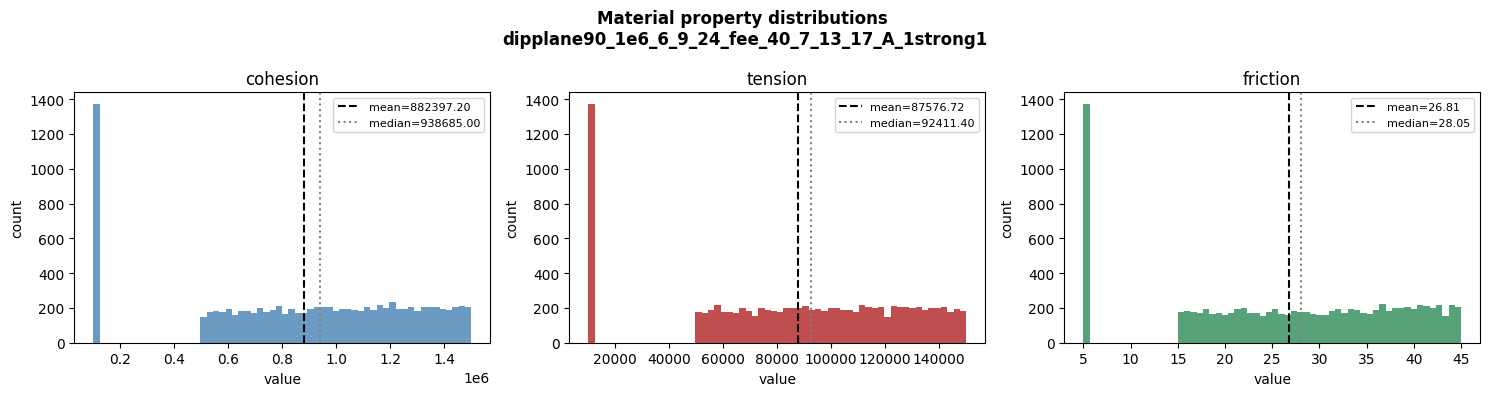

In [53]:
# plot histograms of the strengths

import matplotlib.pyplot as plt
import numpy as np

hist_tag = 'hist_'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

properties = ['cohesion', 'tension', 'friction']
colors = ['steelblue', 'firebrick', 'seagreen']

for ax, prop, color in zip(axes, properties, colors):
    vals = synscape[prop].dropna()
    ax.hist(vals, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(vals.mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'mean={vals.mean():.2f}')
    ax.axvline(vals.median(), color='gray', linestyle=':',
               linewidth=1.5, label=f'median={vals.median():.2f}')
    ax.set_title(prop)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.legend(fontsize=8)
    print(f"{prop}:")
    print(f"  mean={vals.mean():.4f}, std={vals.std():.4f}")
    print(f"  min={vals.min():.4f}, max={vals.max():.4f}")
    print(f"  unique values: {vals.nunique()}")

plt.suptitle('Material property distributions \n' + lscape_name_notxt, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(img_folder + hist_tag + lscape_name_notxt + '.png')
plt.show()

cohesion bin counts:
cohesion
weak      1879
medium    3727
strong    3998
Name: count, dtype: int64

tension bin counts:
tension
weak      1909
medium    3789
strong    3906
Name: count, dtype: int64

friction bin counts:
friction
weak      2268
medium    3450
strong    3886
Name: count, dtype: int64



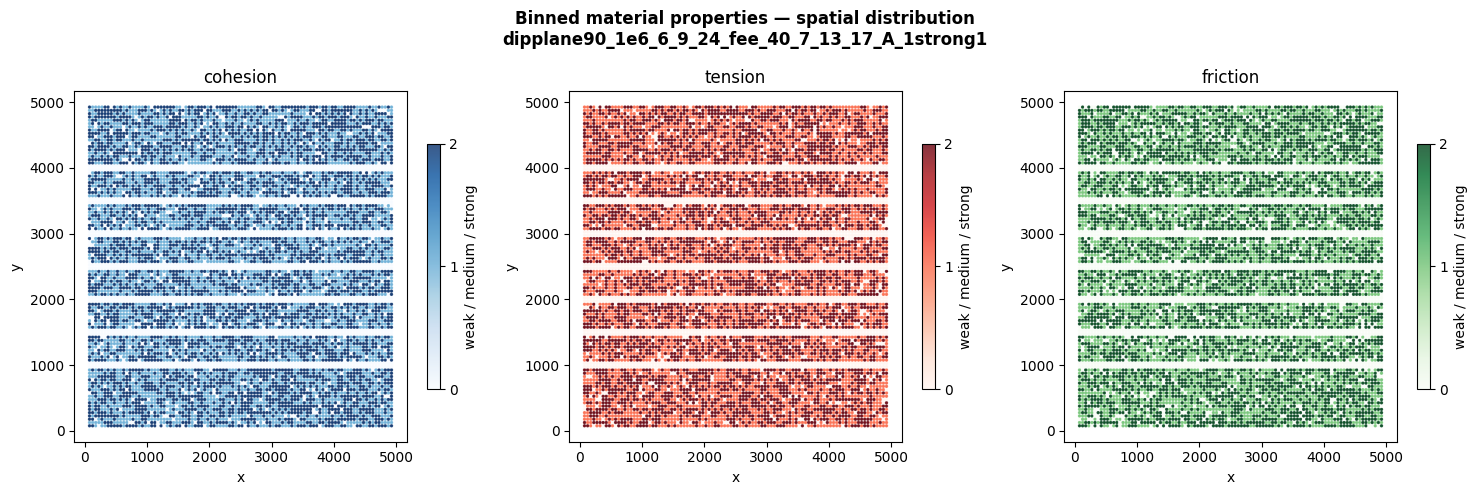

In [54]:
# look at the full spatial distribution of binned properties

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bins_tag = 'matbins_'

properties = ['cohesion', 'tension', 'friction']
colors = ['Blues', 'Reds', 'Greens']

for ax, prop, cmap in zip(axes, properties, colors):
    vals = synscape[prop]
    
    # three equal-width bins across the range
    bins = pd.cut(vals, bins=3, labels=['weak', 'medium', 'strong'])
    bin_codes = pd.cut(vals, bins=3, labels=[0, 1, 2]).astype(float)
    
    scatter = ax.scatter(synscape['x'], synscape['y'],
                         c=bin_codes, cmap=cmap,
                         s=2, alpha=0.8)
    plt.colorbar(scatter, ax=ax, shrink=0.7,
                 ticks=[0, 1, 2],
                 label='weak / medium / strong')
    ax.set_title(prop)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    
    # print bin counts
    print(f"{prop} bin counts:")
    print(bins.value_counts().sort_index())
    print()

plt.suptitle('Binned material properties — spatial distribution\n' + lscape_name_notxt,
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(img_folder + bins_tag + lscape_name_notxt + '.png')
plt.show()

In [55]:
# plot spatial autocorrelation
# Moran's ~0: spatial randomness
# Moran's ~1: spatial clustering

from scipy.spatial.distance import cdist
import numpy as np

# use the raw point cloud -- no gridding needed for autocorrelation
coords = synscape[['x', 'y']].values
properties = ['cohesion', 'tension', 'friction']

# Moran's I for each property
# efficient approximation using a spatial weights matrix
# with a distance threshold

def morans_i(vals, coords, threshold):
    """
    Compute Moran's I spatial autocorrelation.
    threshold: maximum distance for neighbors
    """
    n = len(vals)
    z = vals - vals.mean()
    
    # build spatial weights -- 1 if distance < threshold, 0 otherwise
    # process in chunks to avoid memory issues with 9604x9604 matrix
    W_sum = 0.0
    num = 0.0
    
    chunk = 500
    for i in range(0, n, chunk):
        i_end = min(i + chunk, n)
        dists = cdist(coords[i:i_end], coords)
        w = ((dists > 0) & (dists < threshold)).astype(float)
        num += (w * z[i:i_end, None] * z[None, :]).sum()
        W_sum += w.sum()
    
    denom = (z ** 2).sum()
    I = (n / W_sum) * (num / denom)
    return I

# use grid spacing as threshold -- connects immediate neighbors only
# grid spacing is approximately 50 units
threshold = 75  # slightly larger than grid spacing to catch all immediate neighbors

print(f"Moran's I with distance threshold={threshold} units (grid squares are 50 units/side)")
print(f"(immediate neighbors only)\n")

for prop in properties:
    vals = synscape[prop].values.astype(float)
    I = morans_i(vals, coords, threshold)
    print(f"{prop}: Moran's I = {I:.6f}")
    # Moran's I interpretation:
    # ~0   = spatially random
    # ~1   = perfectly clustered
    # ~-1  = perfectly dispersed

Moran's I with distance threshold=75 units (grid squares are 50 units/side)
(immediate neighbors only)

cohesion: Moran's I = 0.332991
tension: Moran's I = 0.336269
friction: Moran's I = 0.311974


In [51]:
# for friction check, isolate Moran's
# of upper grid domain only

# isolate upper domain -- above the initial condition divide
upper = synscape[synscape['y'] > 1200].copy()

print(f"upper domain points: {len(upper)}")
print(f"friction stats above divide:")
print(upper['friction'].describe())

# Moran's I for friction in upper domain only
coords_upper = upper[['x','y']].values
I_upper = morans_i(upper['friction'].values.astype(float), 
                   coords_upper, threshold=75)
print(f"\nMoran's I friction (upper domain only): {I_upper:.6f}")

# compare to cohesion in upper domain
I_coh_upper = morans_i(upper['cohesion'].values.astype(float),
                        coords_upper, threshold=75)
print(f"Moran's I cohesion (upper domain only): {I_coh_upper:.6f}")

upper domain points: 7350
friction stats above divide:
count    7350.000000
mean       30.072688
std         9.066412
min         5.000000
25%        22.457700
50%        30.313200
75%        37.983875
max        44.995600
Name: friction, dtype: float64

Moran's I friction (upper domain only): 0.015807
Moran's I cohesion (upper domain only): 0.009674
